# Quantum Pattern Generation — FRQI
In the first challenge, Quantum Image Lab: The FRQI Challenge, you were introduced to the FRQI encoding of an image into a quantum state.

It is now time to deep dive into the transformation and generation of quantum visuals using the FRQI encoding.
You will be given target patterns and tasked to build a FRQI circuit that can reproduce them.

### Challenge Outline
1. **Random Noise**

2. **Quantum Checkerboard**

3. **Horizontal and vertical lines**

4. **Nested Squares**

5. **Grayscale Nested Squares**

6. **Quantum Fractals** *(bonus)*


In [ ]:
from pathlib import Path
import sys

utils_dir = Path("notebooks/iqucodefest-2026-main/side_quests/challenge_02_generative_quantum_art")
utils_dir = utils_dir.resolve() if utils_dir.exists() else Path.cwd().resolve()

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

print(f"Using utilities from: {utils_dir}")


In [ ]:
import math
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np
import matplotlib.pyplot as plt
import importlib
from pathlib import Path
import sys

utils_dir = Path("notebooks/iqucodefest-2026-main/side_quests/challenge_02_generative_quantum_art")
utils_dir = utils_dir.resolve() if utils_dir.exists() else Path.cwd().resolve()
if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Import utility functions
import utils_quantum
importlib.reload(utils_quantum)
import utils_images
importlib.reload(utils_images)
from utils_quantum import run_simulation
from utils_images import display_image
import utils_images as img_utils
import utils_quantum as q_utils

print(f"utils_images loaded from: {img_utils.__file__}")
print(f"utils_quantum loaded from: {q_utils.__file__}")

In [31]:
import math
import numpy as np
from qiskit import QuantumCircuit

def _apply_x_mask(qc: QuantumCircuit, address_bitstring: str, position_qubits: list[int]):
    """
    Apply an X-mask to emulate controls-on-0 for an address.

    Args:
    - qc: QuantumCircuit to modify.
    - address_bitstring: "natural" binary string (MSB on the left), e.g. "0101".
    - position_qubits: ordered list of position-qubit indices (q0 = LSB).
      Note: if position_qubits == [0, 1, 2, ...], then position_qubits[i] == i.
    """
    # Reverse so index 0 aligns with q0 (LSB)
    for bit_idx, bit in enumerate(reversed(address_bitstring)):
        if bit == "0":
            qc.x(position_qubits[bit_idx])

In [32]:
def encode_frqi_simple(binary_image: np.ndarray) -> tuple[QuantumCircuit, int]:
    """
    FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    flat = np.array(binary_image).astype(int).flatten() # flatten to 1D array row-major order: row0, row1, ...
    n_pixels = len(flat)
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels)) # number of position qubits
    n_total = n_pos + 1                    # +1 color qubit
    pos_qubits = list(range(n_pos))        # q0..q(k-1)
    color_qubit = n_pos                    # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")
    
    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    qc.h(pos_qubits)

    # Step 2) Encode black pixels with MCX
    for i, pixel_val in enumerate(flat):
        if int(pixel_val) != 1:         # only encode black pixels (value 1)
            continue

        address_bitstring = format(i, f"0{n_pos}b")  # MSB..LSB (natural)

        _apply_x_mask(qc, address_bitstring, pos_qubits) # apply X-mask for controls-on-0
        qc.mcx(pos_qubits, color_qubit)                  # Multi-controlled X: flip color qubit when ALL position qubits are |1⟩
        _apply_x_mask(qc, address_bitstring, pos_qubits)  # undo (X is its own inverse)

        qc.barrier() # barrier for visual clarity

        # Note: MCX can apply the sandwiching X gates automatically with the ctrl_state option,

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")
    
    return qc, n_pos # return circuit and number of position qubits

In [33]:
def reconstruct_from_frqi(counts, n_position_qubits, image_shape):
    """
    Reconstruct image from FRQI measurement counts using the 'Ratio' method.
    Args:
    - counts: dict from measurement outcomes to counts.
    - n_position_qubits: number of position qubits used in FRQI.
    - image_shape: tuple (height, width) of the original image.
    
    Returns:
    - reconstructed_image: 2D numpy array of the reconstructed image.
    """
    
    n_pixels = image_shape[0] * image_shape[1] # Total number of pixels
    
    # 1. Accumulate statistics per pixel (Address)
    total_counts = np.zeros(n_pixels, dtype=int)
    ones_counts = np.zeros(n_pixels, dtype=int)
    
    print("Reconstructing image from measurements...\n")
    
    # For each measurement outcome (e.g., '10101')
    for outcome, count in counts.items():
        # Remove spaces if any
        outcome = outcome.replace(" ", "")
        
        # --- VISUAL MAPPING (Left -> High Index) ---
        # The string typically looks like: "C P3 P2 P1 P0"
        # Leftmost character is the Color Qubit
        color_char = outcome[0] 
        
        # The rest is the Position (binary string)
        position_string = outcome[1:]
        
        # Convert "1101" -> 13 (Standard binary: Left is MSB)
        position_idx = int(position_string, 2)
        
        # Only process valid pixel positions
        if position_idx < n_pixels:
            # Accumulate counts for this address
            total_counts[position_idx] += count
            
            # If color bit is 1, count it as a "black" measurement
            if int(color_char) == 1:
                ones_counts[position_idx] += count
    
    # 2. Compute Pixel Values based on Ratio
    reconstructed = np.zeros(n_pixels, dtype=int)
    
    for i in range(n_pixels):
        if total_counts[i] > 0:
            # Calculate proportion of 1s (Intensity)
            ratio = ones_counts[i] / total_counts[i]
            
            # For Binary: Threshold at 50%
            if ratio > 0.5:
                reconstructed[i] = 1
    
    # Reshape to original image dimensions
    reconstructed_image = reconstructed.reshape(image_shape) # from 1D to 2D, row-major order
    
    return reconstructed_image


## Pattern 1 - Random Noise
You must produce a fully random image, like TV static. Each pixel is drawn independently from the others, with a 50% chance of being black and a 50% chance of being white. 

 FRQI circuit created!
   Depth: 100, Size: 227 gates
Reconstructing image from measurements...



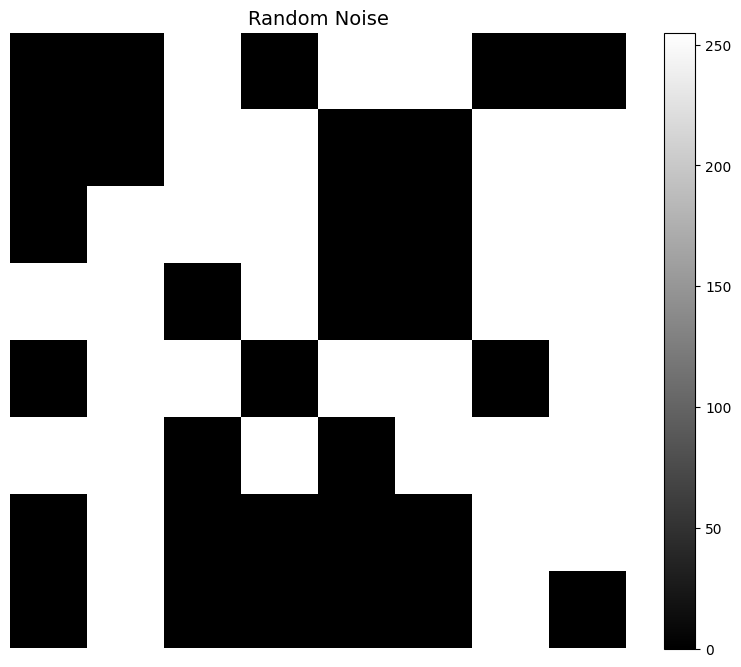

In [34]:
# Instead of a hardcoded pattern like the cross:
random_image = np.random.randint(0, 2, size=(8, 8))  # 0 or 1, each with 50% probability

frqi_circuit, n_pos = encode_frqi_simple(random_image)
frqi_circuit.measure_all()

num_shots = 50 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

reconstructed = reconstruct_from_frqi(counts, n_pos, random_image.shape)
img_utils.display_image(reconstructed * 255, "Random Noise")

## Pattern 2 - Quantum Checkerboard

Create a classic checkerboard pattern, that is, alternating black and white pixels. The circuit is **deterministic**: it always produces the same checkerboard.

Can you also figure out how to obtain the negative from this first circuit?

Note: the checkerboard and its negative are reconstructed separately, using distinct circuits.

## Output 1

 FRQI circuit created!
   Depth: 97, Size: 230 gates
Reconstructing image from measurements...



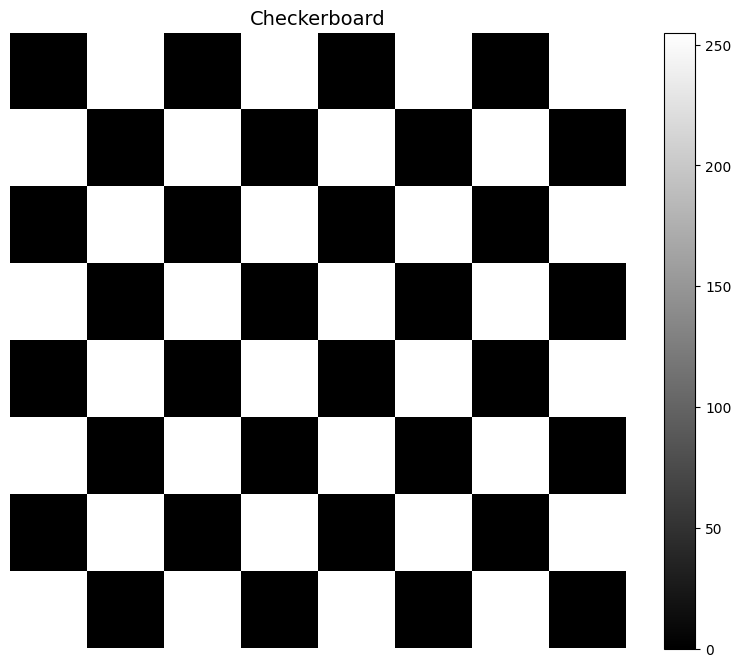

In [35]:
size = 8
checkerboard = np.array([[(y + x) % 2 for x in range(size)] for y in range(size)])

frqi_circuit, n_pos = encode_frqi_simple(checkerboard)
frqi_circuit.measure_all()

num_shots = 50 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)
reconstructed = reconstruct_from_frqi(counts, n_pos, checkerboard.shape)
img_utils.display_image(reconstructed * 255, "Checkerboard")

 FRQI circuit created!
   Depth: 97, Size: 230 gates
Reconstructing image from measurements...



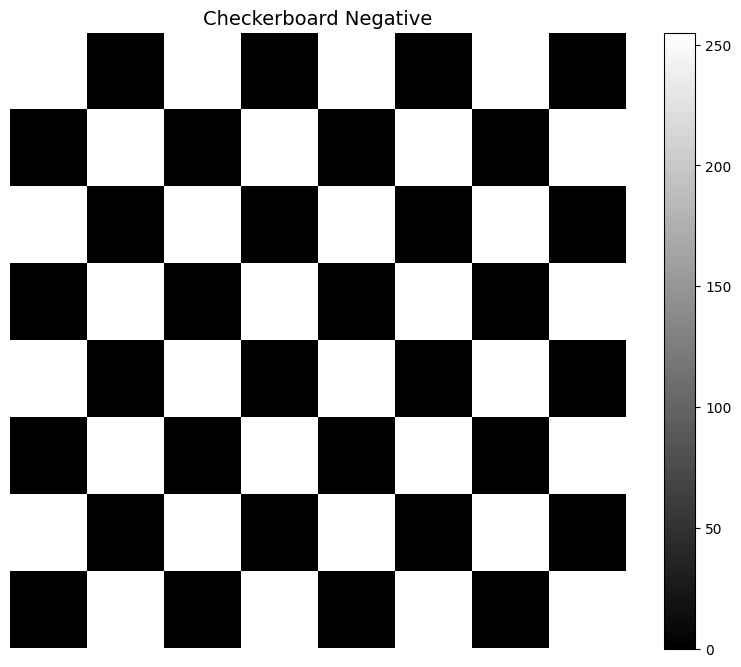

In [36]:
frqi_circuit_neg, n_pos = encode_frqi_simple(checkerboard)
frqi_circuit_neg.x(n_pos)  # flip the color qubit for ALL pixels at once
frqi_circuit_neg.measure_all()

counts_neg = q_utils.run_simulation(frqi_circuit_neg, shots=num_shots)
reconstructed_neg = reconstruct_from_frqi(counts_neg, n_pos, checkerboard.shape)
img_utils.display_image(reconstructed_neg * 255, "Checkerboard Negative")

## Output 2

## Pattern 3 - Horizontal Lines
You must generate alternating black and white horizontal lines that remain the same between each run.


 FRQI circuit created!
   Depth: 97, Size: 262 gates
Reconstructing image from measurements...



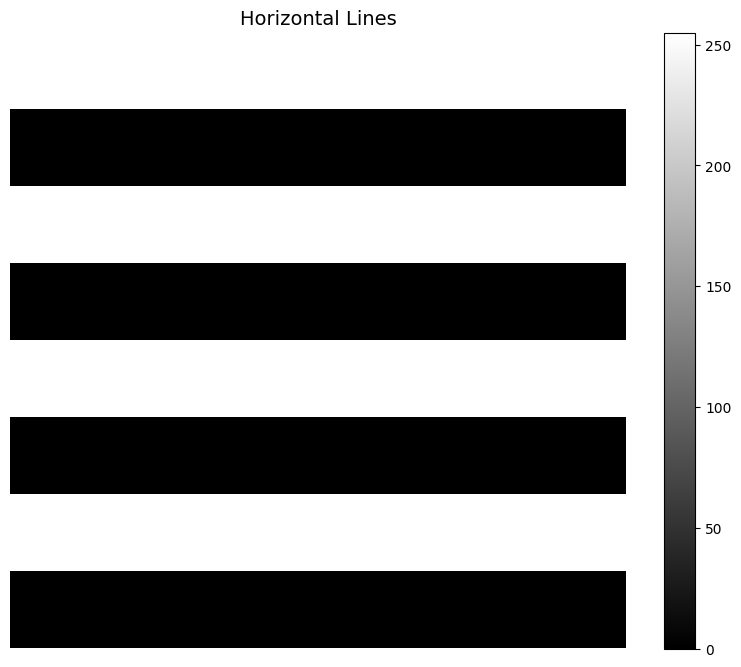

In [37]:
size = 8
horizontal_lines = np.array([[1 if y % 2 == 0 else 0 for x in range(size)] for y in range(size)])

frqi_circuit, n_pos = encode_frqi_simple(horizontal_lines)
frqi_circuit.measure_all()

num_shots = 50 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)
reconstructed = reconstruct_from_frqi(counts, n_pos, horizontal_lines.shape)
img_utils.display_image(reconstructed * 255, "Horizontal Lines")

## Pattern 4 - Vertical Lines
Same idea as pattern 3, but the lines must be vertical just like in the picture below.


 FRQI circuit created!
   Depth: 97, Size: 262 gates
Reconstructing image from measurements...



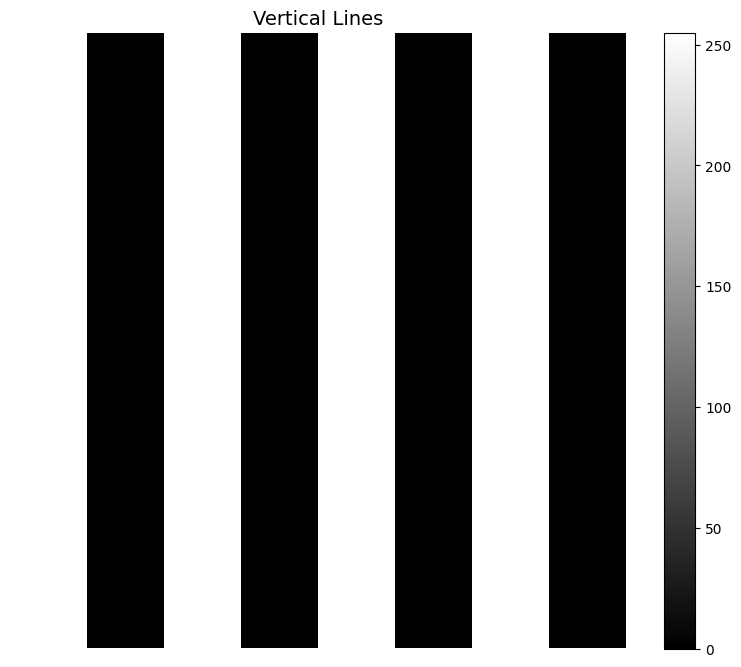

In [38]:
size = 8
vertical_lines = np.array([[1 if x % 2 == 0 else 0 for x in range(size)] for y in range(size)])

frqi_circuit, n_pos = encode_frqi_simple(vertical_lines)
frqi_circuit.measure_all()

num_shots = 50 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)
reconstructed = reconstruct_from_frqi(counts, n_pos, vertical_lines.shape)
img_utils.display_image(reconstructed * 255, "Vertical Lines")

## Pattern 5 - Nested Squares

Here, we want to build concentric rectangles, that is, nested squares that alternate black and white from the outside toward the center. In contrast to the checkerboard and the stripes patterns, each pixel must be handled individually.

To describe this pattern, we consider an image of size $R \times C$:
- $R$ = number of rows
- $C$ = number of columns

For a pixel located at row $r$ and column $c$, we define its **layer** $L(r,c)$ as its distance to the nearest border:

$$
L(r,c) = \min(r, c, R-1-r, C-1-c)
$$

Thus:
- layer $0$ corresponds to the outer border,
- layer $1$ to the first inner rectangle,
- layer $2$ to the next one,
- and so on until the center.

**Your goal:** find an FRQI circuit that reproduces this pattern while respecting the black/white alternation.


 FRQI circuit created!
   Depth: 119, Size: 286 gates
Reconstructing image from measurements...



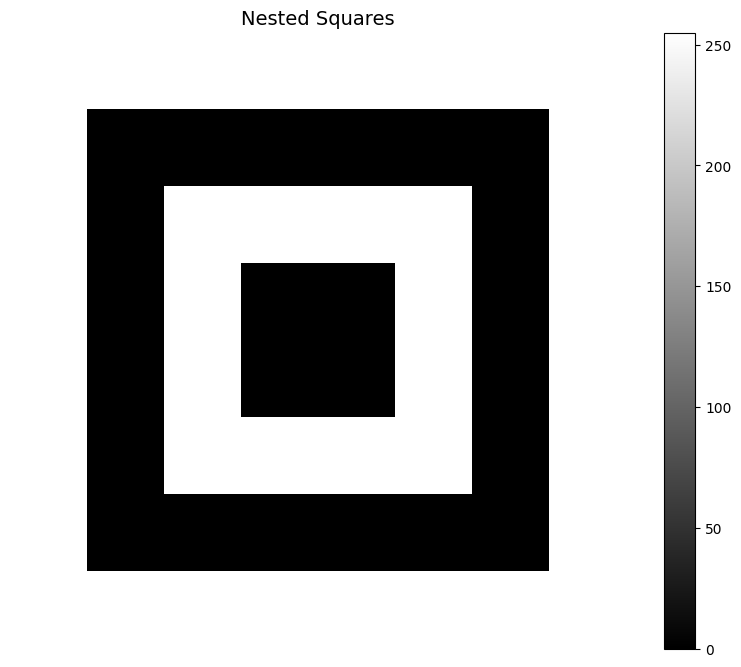

In [39]:
R, C = 8, 8
nested_squares = np.array([
    [1 if min(y, x, R-1-y, C-1-x) % 2 == 0 else 0 for x in range(C)]
    for y in range(R)
])

frqi_circuit, n_pos = encode_frqi_simple(nested_squares)
frqi_circuit.measure_all()

num_shots = 50 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)
reconstructed = reconstruct_from_frqi(counts, n_pos, nested_squares.shape)
img_utils.display_image(reconstructed * 255, "Nested Squares")

## Pattern 6 - Grayscale Nested Squares

Same idea as the Nested Squares in pattern 5, but **each layer has a different intensity**.
You can find how to handle grayscale images using FRQI encoding in challenge 1 Image Lab.

![Grayscale rectangles](images/frqi_carre_gris.png)

## Pattern 7 - Quantum Sierpiński Triangle (Bonus)
This challenge consists of building **a single FRQI circuit** that allows you to reconstruct:
- the **normal** image;
- the **inverted** image.

The idea is that after taking **many measurements**, you obtain **two groups of results** depending on the value of a **selection qubit**, and then you reconstruct one image per group.

The **classical mask** necessary to build the fractal is given below.

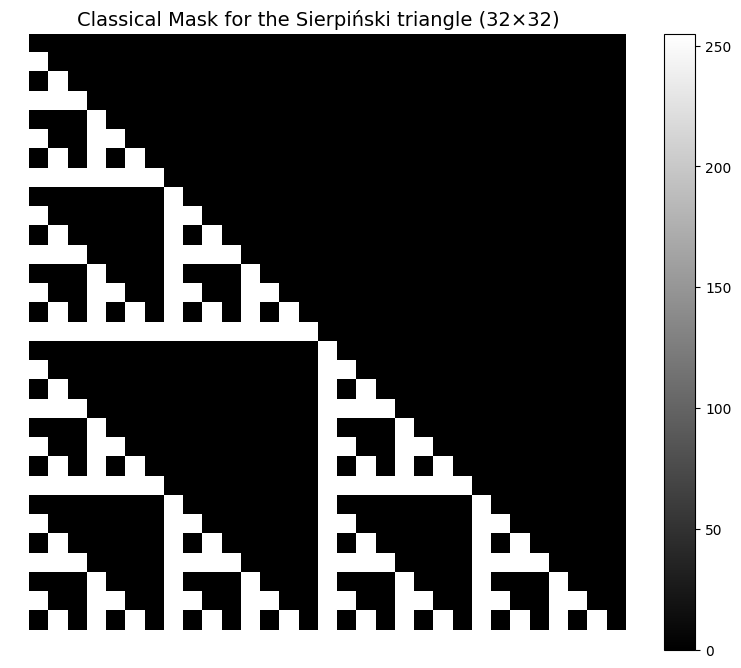

In [41]:
def sierpinski_triangle_mask(size=32):
    """Return a binary mask (size x size) for the Sierpiński triangle."""
    mask = np.zeros((size, size), dtype=int)
    for row in range(size):
        for col in range(size):
            if col <= row and (row & col) == col:
                mask[row, col] = 1
    return mask


size = 32
mask = sierpinski_triangle_mask(size)
display_image(mask * 255, f"Classical Mask for the Sierpiński triangle ({size}×{size})", cmap='gray')